In [2]:
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 폰트 등록
fm.fontManager.addfont(font_path)

# 등록된 폰트 이름 확인
font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

NanumGothic


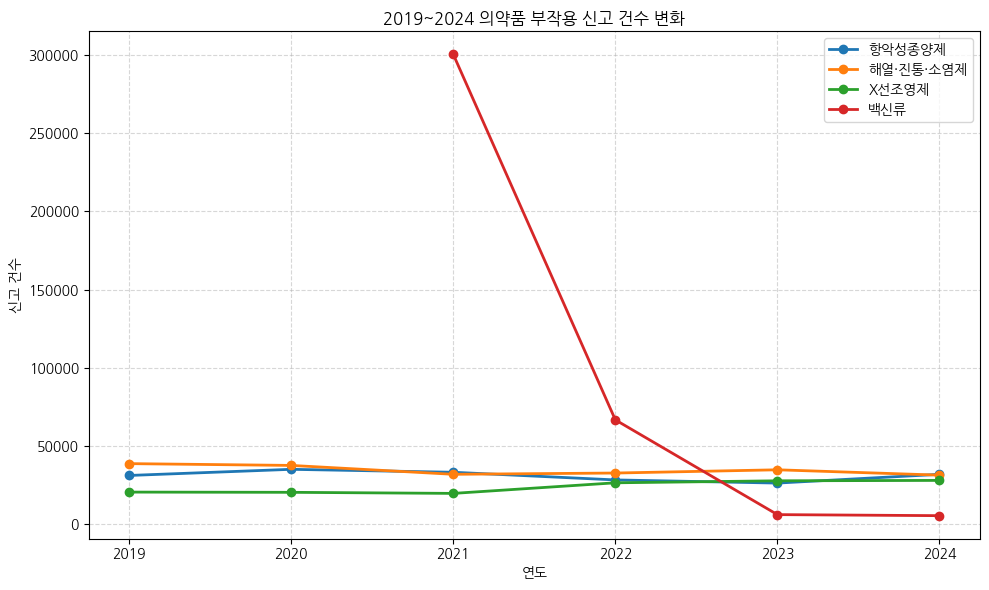

===== 분석 결과 =====
항악성종양제 : 최고 신고 건수 34,951건 (2020년)
해열·진통·소염제 : 최고 신고 건수 38,591건 (2019년)
X선조영제 : 최고 신고 건수 27,859건 (2024년)
백신류 : 최고 신고 건수 300,425건 (2021년)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

# ============================
# 한글 폰트 설정
# ============================
plt.rcParams['font.family'] = 'NanumGothic'   # ← 여기만 나중에 확인해서 수정 가능
plt.rcParams['axes.unicode_minus'] = False

# ============================
# 데이터 불러오기
# ============================
df = pd.read_csv('/workspaces/Daegun26Veritas/data/10727data.csv')

years_to_process = [2019, 2020, 2021, 2022, 2023, 2024]

# ============================
# 데이터 저장 리스트
# ============================
at_data = []
pa_data = []
ct_data = []
vc_data = []

drug_categories_map = {
    '항악성종양제': {'list': at_data, 'names': ['항악성종양제']},
    '해열·진통·소염제': {'list': pa_data, 'names': ['해열·진통·소염제', '해열 진통소염제']},
    'X선조영제': {'list': ct_data, 'names': ['X선조영제']},
    '백신류': {'list': vc_data, 'names': ['백신류']}
}

# ============================
# 데이터 전처리
# ============================
for year in years_to_process:

    symptom_col = f'연도별증상({year})'
    count_col = f'연도별보고건수({year})'

    if symptom_col in df.columns and count_col in df.columns:

        for drug_info in drug_categories_map.values():

            filtered = df[
                df[symptom_col]
                .fillna('')
                .str.strip()
                .isin(drug_info['names'])
            ]

            if not filtered.empty:
                drug_info['list'].append(filtered[count_col].iloc[0])
            else:
                drug_info['list'].append(None)

    else:
        for drug_info in drug_categories_map.values():
            drug_info['list'].append(None)

years = years_to_process

# ============================
# 그래프 그리기
# ============================
plt.figure(figsize=(10,6))

plt.plot(years, at_data, marker='o', linewidth=2, label='항악성종양제')
plt.plot(years, pa_data, marker='o', linewidth=2, label='해열·진통·소염제')
plt.plot(years, ct_data, marker='o', linewidth=2, label='X선조영제')
plt.plot(years, vc_data, marker='o', linewidth=2, label='백신류')

plt.title('2019~2024 의약품 부작용 신고 건수 변화')
plt.xlabel('연도')
plt.ylabel('신고 건수')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

print("===== 분석 결과 =====")

for drug, values in {
    "항악성종양제": at_data,
    "해열·진통·소염제": pa_data,
    "X선조영제": ct_data,
    "백신류": vc_data
}.items():

    valid_values = [v for v in values if v is not None]

    if len(valid_values) == 0:
        print(f"{drug} : 데이터 없음")
        continue

    max_value = max(valid_values)
    max_index = values.index(max_value)
    max_year = years[max_index]

    print(f"{drug} : 최고 신고 건수 {max_value:,}건 ({max_year}년)")

# 의약품 부작용 신고 데이터 분석 프로젝트

## 프로젝트 주제

**2019~2024년 의약품 효능군별 부작용 신고 건수 변화 분석**


---

# 사용한 데이터

- **출처** : 공공데이터포털
- **제공기관** : 한국의약품안전관리원
- **데이터명** : 연도별 효능군별 이상사례 보고현황

---

# 사용한 개발 환경

- GitHub Codespaces
- Python
- Pandas
- Matplotlib

---

# 분석 결과

## 항악성종양제

- 전체적으로 2만~3만 건 수준을 유지하였다.
- 연도별 증감은 있었지만 큰 변화는 나타나지 않았다.

## 해열·진통·소염제

- 약 3만 건 수준을 유지하였다.
- 가장 안정적인 변화 양상을 보였다.

## X선조영제

- 2022년 이후 신고 건수가 증가하는 경향을 보였다.
- 사용량 증가 등 여러 요인의 영향을 받았을 가능성이 있다.

## 백신류

- 2021년에 약 30만 건으로 가장 높은 신고 건수를 기록하였다.
- 이후 2022년부터 급격히 감소하였다.

---

# 결과 해석

백신류의 신고 건수가 2021년에 크게 증가한 것은
코로나19 백신 접종이 전국적으로 실시되면서
접종 대상자가 급격히 증가한 영향으로 해석할 수 있다.

이후 코로나19 유행이 완화되고
추가 접종 대상이 감소하면서
백신 관련 부작용 신고 건수도 빠르게 감소하였다.

반면 항악성종양제와 해열·진통·소염제는
일상적으로 지속적으로 사용되는 의약품이기 때문에
큰 변화 없이 일정한 신고 건수를 유지한 것으로 나타났다.

---

# 프로젝트를 통해 배운 점

이번 프로젝트를 통해 공공데이터를 활용하여
Python으로 데이터를 전처리하고 시각화하는 과정을 직접 경험하였다.

처음에는 정리된 숫자를 입력해 그래프를 만드는 수준이였지만,
실제 CSV 파일에서 필요한 효능군 데이터를 자동으로 추출하도록 프로그램을 개선하면서
데이터 분석은 결과보다 데이터를 다루는 과정이 더 중요하다는 점을 느꼈다.

또한 그래프의 수치만 확인하는 것이 아니라,
데이터 변화의 원인을 사회적 상황과 함께 해석하는 과정이
분석의 신뢰성을 높인다는 점도 알게 되었다.

특히 2021년 백신류 이상사례 보고 건수가 크게 증가한 이유를
코로나19 백신 접종 확대와 연결하여 해석하면서,
데이터는 사회적 배경과 함께 분석해야 의미 있는 정보가 된다는 점을 확인할 수 있었다.

이번 프로젝트를 통해 프로그래밍은 단순히 결과를 출력하는 도구가 아니라,
공공데이터에서 필요한 정보를 추출하고 객관적인 근거를 바탕으로
현상을 분석하는 탐구 도구가 될 수 있음을 경험하였다.
이는 의약품의 안전성과 부작용을 데이터 기반으로 분석하는
약학 분야에서도 중요한 역량이라는 점을 느꼈다.

---

# 진로와 프로젝트 사이의 나의 생각

약사는 의약품을 조제하는 역할뿐 아니라
의약품 부작용을 지속적으로 모니터링하고
환자에게 안전한 약물 사용 정보를 제공하는 역할도 수행한다.

이번 프로젝트를 통해 데이터 분석 능력이
약학 분야에서도 매우 중요한 역량이라는 것을 알게 되었으며,
앞으로도 다양한 의약품 안전 데이터를 분석해 보고 싶다는 생각이 들었다.
